<a href="https://colab.research.google.com/github/sadhika-tech/deep-learning-lab/blob/main/Lab%206/rnn_lstm_gru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!wget https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip -O /content/har.zip

--2026-09-23 07:54:32--  https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘/content/har.zip’

/content/har.zip        [                <=> ]  58.18M  16.8MB/s    in 4.4s    

2026-09-23 07:54:38 (13.1 MB/s) - ‘/content/har.zip’ saved [61005872]



In [4]:
!unzip -q /content/har.zip -d /content/

In [5]:
!ls "/content"

 drive	 har.zip   sample_data	'UCI HAR Dataset.names'  'UCI HAR Dataset.zip'


In [6]:
!unzip -q "/content/UCI HAR Dataset.zip" -d "/content/"

In [7]:
!ls "/content/UCI HAR Dataset"

activity_labels.txt  features_info.txt	features.txt  README.txt  test	train


In [8]:
!ls "/content/UCI HAR Dataset/train/Inertial Signals/body_acc_x_train.txt"

'/content/UCI HAR Dataset/train/Inertial Signals/body_acc_x_train.txt'


In [9]:
import os, time, zipfile, io, requests, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

In [10]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

ACTIVITIES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
              "SITTING", "STANDING", "LAYING"]

In [11]:
DATA_DIR = "/content/UCI HAR Dataset"

SIGNALS = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

def load_signals(split):
    base = os.path.join(DATA_DIR, split, "Inertial Signals")
    data = []
    for sig in SIGNALS:
        path = os.path.join(base, f"{sig}_{split}.txt")
        arr = np.loadtxt(path)
        data.append(arr)
    # (channels, N, 128) -> (N, 128, channels)
    return np.transpose(np.array(data), (1, 2, 0))

def load_labels(split):
    path = os.path.join(DATA_DIR, split, f"y_{split}.txt")
    return np.loadtxt(path).astype(int) - 1  # 0-indexed, 6 classes

X_train_full = load_signals("train")
y_train_full = load_labels("train")
X_test_full = load_signals("test")
y_test_full = load_labels("test")

In [12]:
print("Full train:", X_train_full.shape, "Full test:", X_test_full.shape)

Full train: (7352, 128, 9) Full test: (2947, 128, 9)


In [13]:
N_SUBSET = 2400

rng = np.random.default_rng(SEED)
idx_by_class = {c: np.where(y_train_full == c)[0] for c in range(6)}
per_class = N_SUBSET // 6
subset_idx = np.concatenate([
    rng.choice(idx_by_class[c], size=min(per_class, len(idx_by_class[c])), replace=False)
    for c in range(6)
])
rng.shuffle(subset_idx)

X_sub, y_sub = X_train_full[subset_idx], y_train_full[subset_idx]
print("Subset shape:", X_sub.shape, "Class counts:", np.bincount(y_sub))

Subset shape: (2400, 128, 9) Class counts: [400 400 400 400 400 400]


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_sub, y_sub, test_size=0.30, stratify=y_sub, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

# Normalize using TRAIN statistics only
mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8
X_train_n = (X_train - mean) / std
X_val_n = (X_val - mean) / std
X_test_n = (X_test - mean) / std

print("Input tensor shape:")
print(f"  Training   : {X_train_n.shape}")
print(f"  Validation : {X_val_n.shape}")
print(f"  Testing    : {X_test_n.shape}")
print(f"Number of classes: 6")
print(f"Number of features per time step: {X_train_n.shape[2]}")
print(f"Sequence length: {X_train_n.shape[1]}")

print("\nClass distribution (train):", np.bincount(y_train))
print("Class distribution (val)  :", np.bincount(y_val))
print("Class distribution (test) :", np.bincount(y_test))

Input tensor shape:
  Training   : (1680, 128, 9)
  Validation : (360, 128, 9)
  Testing    : (360, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128

Class distribution (train): [280 280 280 280 280 280]
Class distribution (val)  : [60 60 60 60 60 60]
Class distribution (test) : [60 60 60 60 60 60]


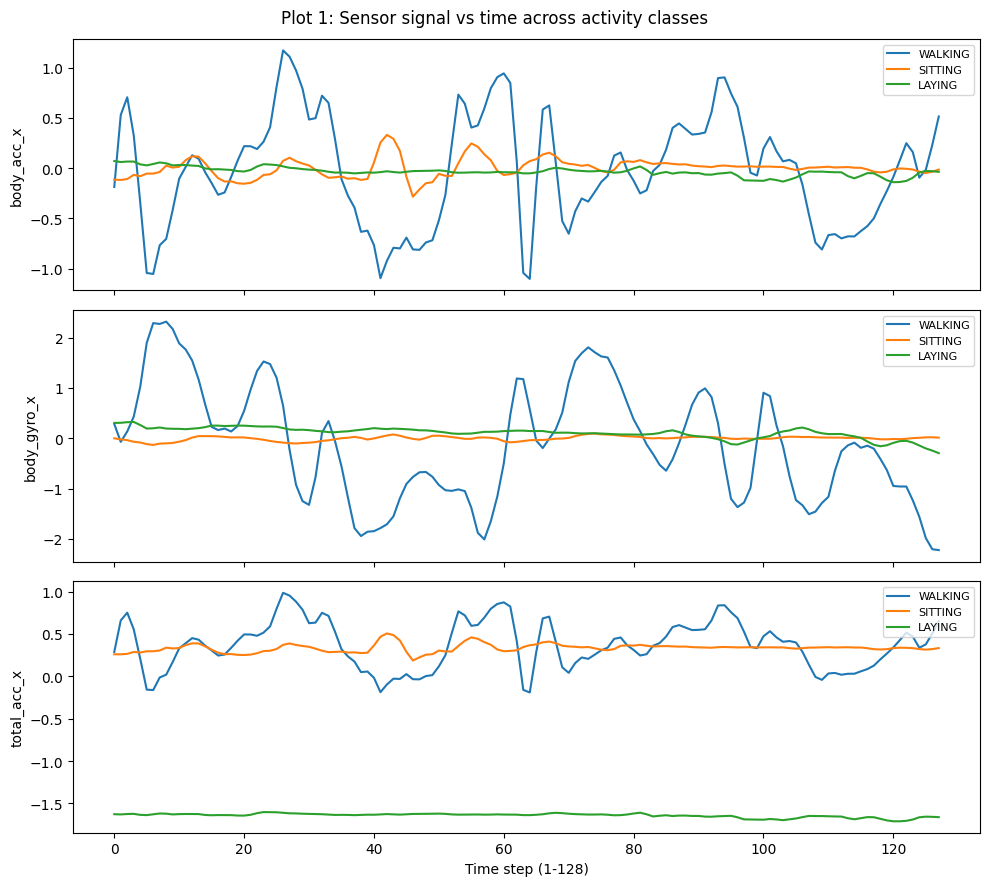

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
chan_names = ["body_acc_x", "body_gyro_x", "total_acc_x"]
chan_idx = [SIGNALS.index(c) for c in chan_names]
example_classes = [0, 3, 5]  # WALKING, SITTING, LAYING

for ax, ch, ch_name in zip(axes, chan_idx, chan_names):
    for c in example_classes:
        sample_idx = np.where(y_train == c)[0][0]
        ax.plot(X_train_n[sample_idx, :, ch], label=ACTIVITIES[c])
    ax.set_ylabel(ch_name)
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("Time step (1-128)")
fig.suptitle("Plot 1: Sensor signal vs time across activity classes")
plt.tight_layout()
plt.show()


In [16]:
def manual_rnn_step(x, h_prev, Wx=0.5, Wh=0.8, b=0.1):
    return np.tanh(Wx * x + Wh * h_prev + b)

x_vals = [0.5, 0.7, 0.2]
h = 0.0
h_history = []
for t, x in enumerate(x_vals, start=1):
    h = manual_rnn_step(x, h)
    h_history.append(h)
    print(f"h{t} = {h:.6f}")

print("\nCompare with a 1-unit SimpleRNN cell:")
cell = layers.SimpleRNNCell(1, activation='tanh',
                             kernel_initializer=tf.constant_initializer(0.5),
                             recurrent_initializer=tf.constant_initializer(0.8),
                             bias_initializer=tf.constant_initializer(0.1))
state = [tf.zeros((1, 1))]
for t, x in enumerate(x_vals, start=1):
    out, state = cell(tf.constant([[x]], dtype=tf.float32), state)
    print(f"h{t} (Keras) = {out.numpy()[0,0]:.6f}")

h1 = 0.336376
h2 = 0.616352
h3 = 0.599958

Compare with a 1-unit SimpleRNN cell:
h1 (Keras) = 0.336376
h2 (Keras) = 0.616352
h3 (Keras) = 0.599958


In [17]:
def build_model(rnn_type, seq_len=128, n_features=9, units=32, n_classes=6):
    RecurrentLayer = {"RNN": layers.SimpleRNN, "LSTM": layers.LSTM, "GRU": layers.GRU}[rnn_type]
    model = models.Sequential([
        Input(shape=(seq_len, n_features)),
        RecurrentLayer(units),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ], name=f"{rnn_type}_classifier")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def train_and_time(model, X_tr, y_tr, X_v, y_v, epochs=30, batch_size=32, verbose=0):
    start = time.time()
    history = model.fit(X_tr, y_tr, validation_data=(X_v, y_v),
                         epochs=epochs, batch_size=batch_size, verbose=verbose)
    elapsed = time.time() - start
    return history, elapsed

for rt in ["RNN", "LSTM", "GRU"]:
    build_model(rt).summary()

Model: "RNN_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "GRU_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
EPOCHS = 30
results = {}
histories = {}

for rnn_type in ["RNN", "LSTM", "GRU"]:
    print(f"\n=== Training {rnn_type} ===")
    model = build_model(rnn_type)
    history, train_time = train_and_time(model, X_train_n, y_train, X_val_n, y_val,
                                          epochs=EPOCHS, verbose=1)
    histories[rnn_type] = history
    results[rnn_type] = {"model": model, "train_time": train_time,
                          "params": model.count_params()}
    print(f"{rnn_type} trained in {train_time:.2f}s, params={model.count_params()}")


=== Training RNN ===
Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 132ms/step - accuracy: 0.3863 - loss: 1.6035 - val_accuracy: 0.5222 - val_loss: 1.3763
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5274 - loss: 1.2864 - val_accuracy: 0.5861 - val_loss: 1.1749
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5899 - loss: 1.1143 - val_accuracy: 0.6500 - val_loss: 0.9924
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6232 - loss: 0.9740 - val_accuracy: 0.6806 - val_loss: 0.8848
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6738 - loss: 0.8659 - val_accuracy: 0.6861 - val_loss: 0.7861
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7018 - loss: 0.7922 - val_accuracy: 0.6972 - val_loss: 0.7429
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6911 - loss: 0.7532 - val_accuracy: 0.6722 - val_loss: 0.9481
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.6827 - loss: 0.8033 - 

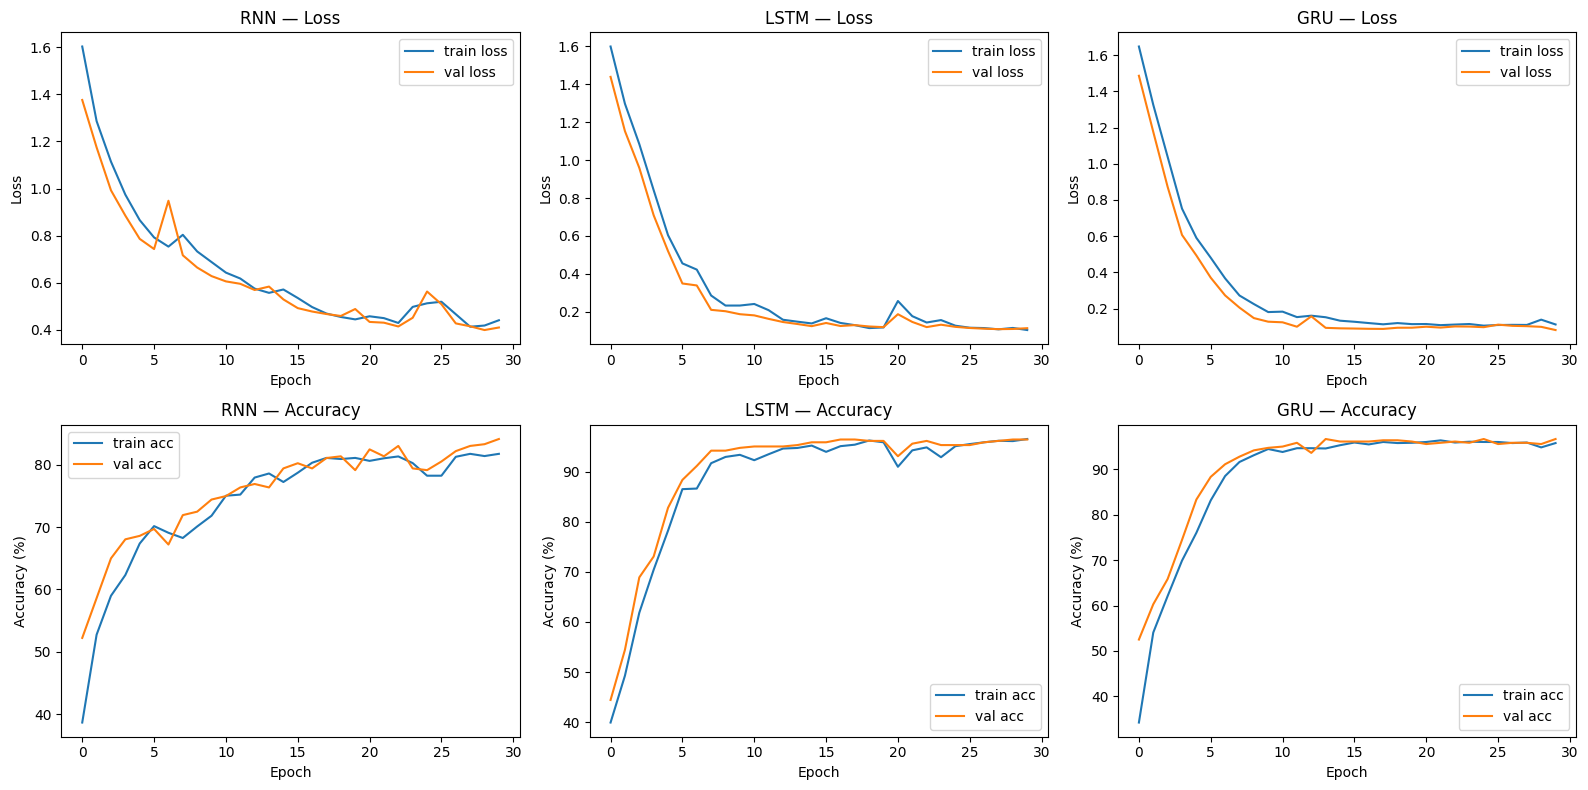

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 8))
for i, rnn_type in enumerate(["RNN", "LSTM", "GRU"]):
    h = histories[rnn_type].history
    axes[0, i].plot(h["loss"], label="train loss")
    axes[0, i].plot(h["val_loss"], label="val loss")
    axes[0, i].set_title(f"{rnn_type} — Loss")
    axes[0, i].set_xlabel("Epoch"); axes[0, i].set_ylabel("Loss"); axes[0, i].legend()
fig, axes = plt.subplots(1, 3, figsize=(16, 8))
for i, rnn_type in enumerate(["RNN", "LSTM", "GRU"]):
    h = histories[rnn_type].history
    axes[0, i].plot(np.array(h["accuracy"]) * 100, label="train acc")
    axes[0, i].plot(np.array(h["val_accuracy"]) * 100, label="val acc")
    axes[0, i].set_title(f"{rnn_type} — Accuracy")
    axes[0, i].set_xlabel("Epoch"); axes[1, i].set_ylabel("Accuracy (%)"); axes[1, i].legend()

plt.tight_layout()
plt.show()

In [20]:
def evaluate_model(model, X_te, y_te, name):
    y_prob = model.predict(X_te, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    acc = accuracy_score(y_te, y_pred) * 100
    prec = precision_score(y_te, y_pred, average="macro", zero_division=0) * 100
    rec = recall_score(y_te, y_pred, average="macro", zero_division=0) * 100
    f1 = f1_score(y_te, y_pred, average="macro", zero_division=0) * 100
    cm = confusion_matrix(y_te, y_pred)
    return {"name": name, "accuracy": acc, "precision": prec, "recall": rec,
            "f1": f1, "confusion_matrix": cm, "y_pred": y_pred}

eval_results = {}
for rnn_type in ["RNN", "LSTM", "GRU"]:
    eval_results[rnn_type] = evaluate_model(results[rnn_type]["model"], X_test_n, y_test, rnn_type)
    r = eval_results[rnn_type]
    print(f"{rnn_type}: Acc={r['accuracy']:.2f}%  Prec={r['precision']:.2f}%  "
          f"Rec={r['recall']:.2f}%  F1={r['f1']:.2f}%")

RNN: Acc=81.67%  Prec=82.23%  Rec=81.67%  F1=81.13%
LSTM: Acc=94.17%  Prec=94.12%  Rec=94.17%  F1=94.13%
GRU: Acc=95.00%  Prec=95.03%  Rec=95.00%  F1=95.00%


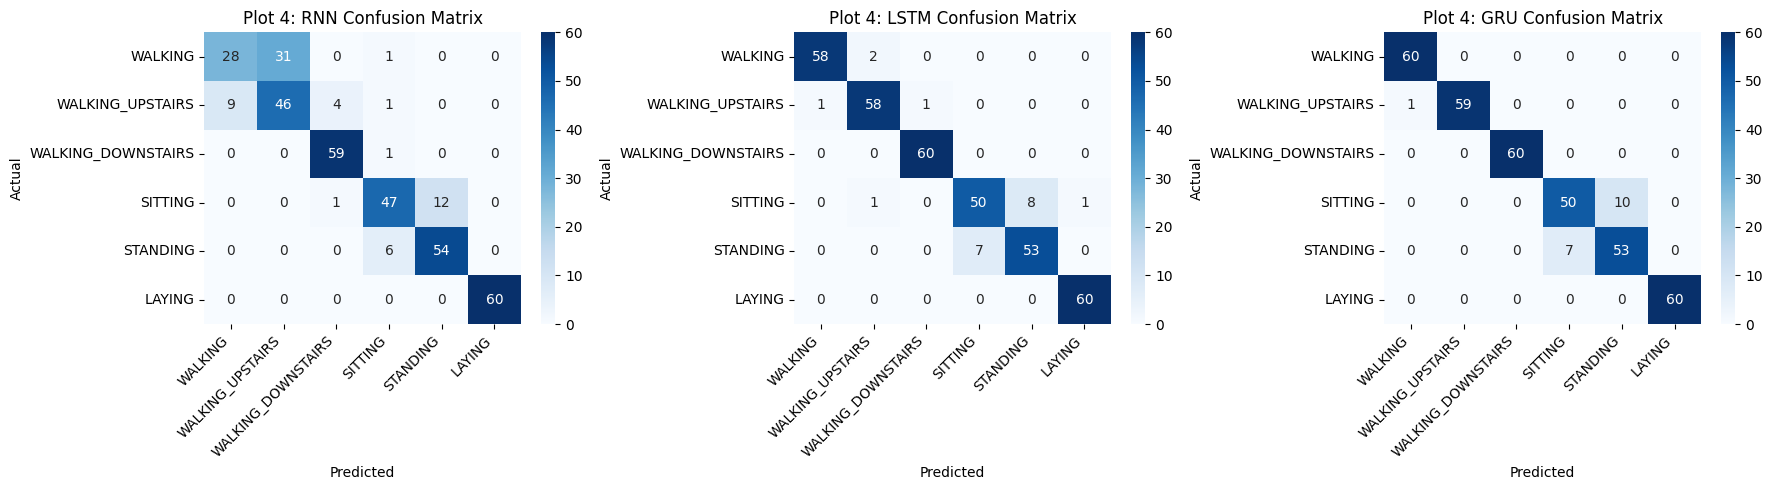

RNN: highest recognition = LAYING; most-confused pair = WALKING -> WALKING_UPSTAIRS (31 instances)
LSTM: highest recognition = WALKING_DOWNSTAIRS; most-confused pair = SITTING -> STANDING (8 instances)
GRU: highest recognition = WALKING; most-confused pair = SITTING -> STANDING (10 instances)


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, rnn_type in zip(axes, ["RNN", "LSTM", "GRU"]):
    cm = eval_results[rnn_type]["confusion_matrix"]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=ACTIVITIES, yticklabels=ACTIVITIES)
    ax.set_title(f"Plot 4: {rnn_type} Confusion Matrix")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

for rnn_type in ["RNN", "LSTM", "GRU"]:
    cm = eval_results[rnn_type]["confusion_matrix"]
    best = ACTIVITIES[np.argmax(np.diag(cm))]
    off_diag = cm.copy(); np.fill_diagonal(off_diag, 0)
    worst_pair_idx = np.unravel_index(np.argmax(off_diag), off_diag.shape)
    print(f"{rnn_type}: highest recognition = {best}; most-confused pair = "
          f"{ACTIVITIES[worst_pair_idx[0]]} -> {ACTIVITIES[worst_pair_idx[1]]} "
          f"({off_diag[worst_pair_idx]} instances)")

In [22]:
gate_info = {
    "RNN":  dict(hidden="Yes", cell="No",  forget="No",  input="No",  output="No",  update="No",  reset="No"),
    "LSTM": dict(hidden="Yes", cell="Yes", forget="Yes", input="Yes", output="Yes", update="No",  reset="No"),
    "GRU":  dict(hidden="Yes", cell="No",  forget="No",  input="No",  output="No",  update="Yes", reset="Yes"),
}

comparison_rows = []
for rnn_type in ["RNN", "LSTM", "GRU"]:
    g = gate_info[rnn_type]
    r = eval_results[rnn_type]
    comparison_rows.append({
        "Property": rnn_type, **g,
        "Parameters": results[rnn_type]["params"],
        "Training time (s)": round(results[rnn_type]["train_time"], 2),
        "Test F1-score (%)": round(r["f1"], 2),
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("Property")
comparison_df

,hidden,cell,forget,input,output,update,reset,Parameters,Training time (s),Test F1-score (%)
Property,,,,,,,,,,
RNN,Yes,No,No,No,No,No,No,1974,47.82,81.13
LSTM,Yes,Yes,Yes,Yes,Yes,No,No,6006,25.30,94.13
GRU,Yes,No,No,No,No,Yes,Yes,4758,22.84,95.00


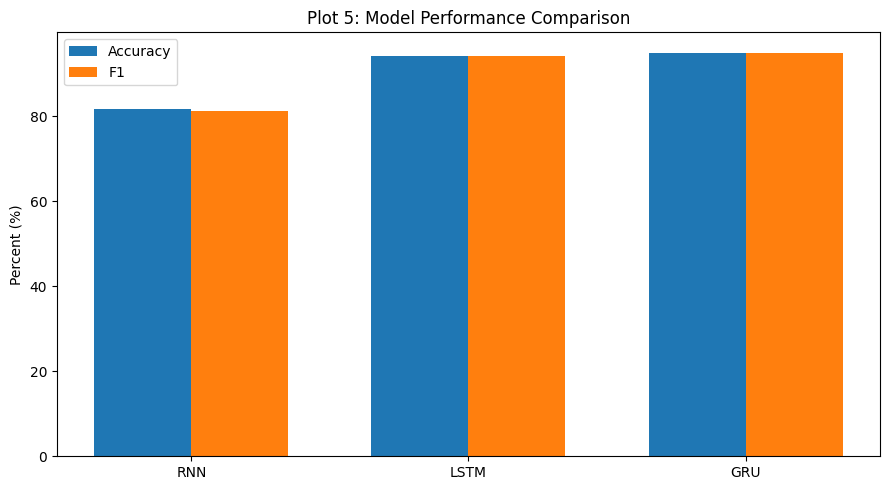

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
metrics_to_plot = ["accuracy", "f1"]
x = np.arange(3)
width = 0.35
for i, m in enumerate(metrics_to_plot):
    vals = [eval_results[rt][m] for rt in ["RNN", "LSTM", "GRU"]]
    ax.bar(x + i * width, vals, width, label=m.capitalize())
ax.set_xticks(x + width / 2)
ax.set_xticklabels(["RNN", "LSTM", "GRU"])
ax.set_ylabel("Percent (%)")
ax.set_title("Plot 5: Model Performance Comparison")
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
def truncate_seq(X, T):
    return X[:, :T, :]

seq_lengths = [32, 64, 128]
seqlen_results = {rt: {} for rt in ["RNN", "LSTM", "GRU"]}

for T in seq_lengths:
    Xtr_T = truncate_seq(X_train_n, T)
    Xv_T = truncate_seq(X_val_n, T)
    Xte_T = truncate_seq(X_test_n, T)
    for rnn_type in ["RNN", "LSTM", "GRU"]:
        model = build_model(rnn_type, seq_len=T)
        model.fit(Xtr_T, y_train, validation_data=(Xv_T, y_val),
                  epochs=15, batch_size=32, verbose=0)
        y_pred = np.argmax(model.predict(Xte_T, verbose=0), axis=1)
        f1 = f1_score(y_test, y_pred, average="macro", zero_division=0) * 100
        seqlen_results[rnn_type][T] = f1
        print(f"T={T:3d}  {rnn_type}: F1={f1:.2f}%")

seqlen_df = pd.DataFrame(seqlen_results)
seqlen_df.index.name = "Sequence Length"
seqlen_df

T= 32  RNN: F1=74.09%
T= 32  LSTM: F1=91.08%
T= 32  GRU: F1=90.79%
T= 64  RNN: F1=74.02%
T= 64  LSTM: F1=93.91%
T= 64  GRU: F1=93.87%
T=128  RNN: F1=74.02%
T=128  LSTM: F1=91.63%
T=128  GRU: F1=94.19%


,RNN,LSTM,GRU
Sequence Length,,,
32,74.085565,91.075526,90.792410
64,74.015489,93.905263,93.866632
128,74.018283,91.633069,94.186290


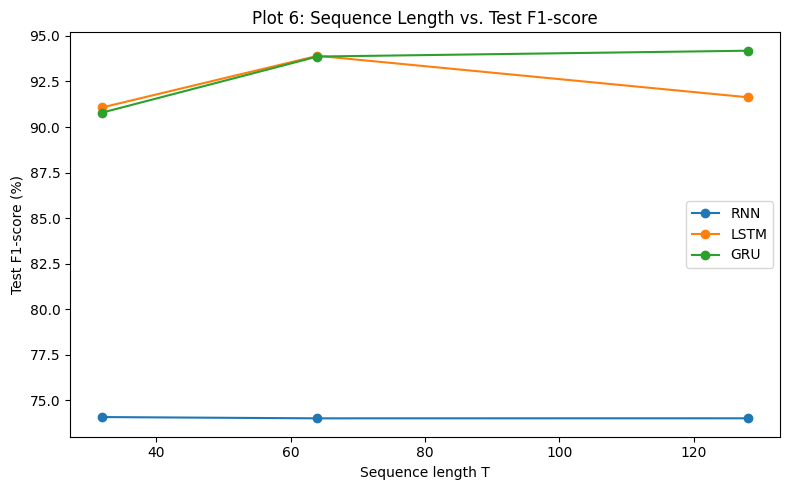

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
for rnn_type in ["RNN", "LSTM", "GRU"]:
    ax.plot(seq_lengths, [seqlen_results[rnn_type][T] for T in seq_lengths],
            marker="o", label=rnn_type)
ax.set_xlabel("Sequence length T")
ax.set_ylabel("Test F1-score (%)")
ax.set_title("Plot 6: Sequence Length vs. Test F1-score")
ax.legend()
plt.tight_layout()
plt.show()

In [26]:
import cv2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

VIDEO_CLASSES = ["Basketball", "Biking", "WalkingWithDog"]
VIDEO_ROOT = "videos"
USE_SAMPLE_VIDEOS = True

if not os.path.isdir(VIDEO_ROOT):
    os.makedirs(VIDEO_ROOT, exist_ok=True)
    for c in VIDEO_CLASSES:
        os.makedirs(os.path.join(VIDEO_ROOT, c), exist_ok=True)
    print(f"Created empty folder structure under '{VIDEO_ROOT}/'. "
          f"Add a few .mp4 clips per class, then re-run this cell onward.")
else:
    print(f"'{VIDEO_ROOT}/' found.")

Created empty folder structure under 'videos/'. Add a few .mp4 clips per class, then re-run this cell onward.


In [27]:
N_FRAMES = 10
FRAME_SIZE = (224, 224)

def sample_frames(video_path, n_frames=N_FRAMES, size=FRAME_SIZE):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return None
    idxs = np.linspace(0, max(total - 1, 0), n_frames).astype(int)
    frames = []
    for i in range(total):
        ret, frame = cap.read()
        if not ret:
            break
        if i in idxs:
            frame = cv2.resize(frame, size)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
    cap.release()
    if len(frames) < n_frames:
        return None
    return np.array(frames[:n_frames])

cnn_extractor = MobileNetV2(include_top=False, weights="imagenet",
                             pooling="avg", input_shape=(224, 224, 3))
cnn_extractor.trainable = False
FEATURE_DIM = cnn_extractor.output_shape[-1]
print("CNN feature dimension D =", FEATURE_DIM)

def extract_video_features(frames):
    x = preprocess_input(frames.astype(np.float32))
    feats = cnn_extractor.predict(x, verbose=0)  # (N_FRAMES, D)
    return feats

video_paths, video_labels = [], []
for ci, c in enumerate(VIDEO_CLASSES):
    folder = os.path.join(VIDEO_ROOT, c)
    for fn in os.listdir(folder):
        if fn.lower().endswith((".mp4", ".avi", ".mov")):
            video_paths.append(os.path.join(folder, fn))
            video_labels.append(ci)

print(f"Found {len(video_paths)} video files across {len(VIDEO_CLASSES)} classes.")

if len(video_paths) == 0:
    print("No videos found yet — add clips under 'videos/<class>/' and re-run this cell "
          "before continuing to the CNN-LSTM training cells below.")
else:
    X_vid_feats, y_vid = [], []
    for path, label in zip(video_paths, video_labels):
        frames = sample_frames(path)
        if frames is None:
            continue
        X_vid_feats.append(extract_video_features(frames))
        y_vid.append(label)
    X_vid_feats = np.array(X_vid_feats)  # (B, 10, D)
    y_vid = np.array(y_vid)
    print("Video feature tensor shape:", X_vid_feats.shape)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
CNN feature dimension D = 1280
Found 0 video files across 3 classes.
No videos found yet — add clips under 'videos/<class>/' and re-run this cell before continuing to the CNN-LSTM training cells below.


In [28]:
if len(video_paths) > 0 and len(X_vid_feats) >= 6:
    Xv_tr, Xv_te, yv_tr, yv_te = train_test_split(
        X_vid_feats, y_vid, test_size=0.25, stratify=y_vid, random_state=SEED)
    Xv_tr, Xv_val, yv_tr, yv_val = train_test_split(
        Xv_tr, yv_tr, test_size=0.2, stratify=yv_tr, random_state=SEED)

    def build_video_model(rnn_type="LSTM", n_classes=len(VIDEO_CLASSES)):
        RecurrentLayer = {"LSTM": layers.LSTM, "GRU": layers.GRU}[rnn_type]
        m = models.Sequential([
            Input(shape=(N_FRAMES, FEATURE_DIM)),
            RecurrentLayer(32),
            layers.Dense(16, activation="relu"),
            layers.Dense(n_classes, activation="softmax"),
        ])
        m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        return m

    video_model = build_video_model("LSTM")
    vid_history = video_model.fit(Xv_tr, yv_tr, validation_data=(Xv_val, yv_val),
                                   epochs=20, batch_size=4, verbose=1)

    y_vid_prob = video_model.predict(Xv_te, verbose=0)
    y_vid_pred = np.argmax(y_vid_prob, axis=1)
    for i in range(len(Xv_te)):
        print(f"Predicted class: {VIDEO_CLASSES[y_vid_pred[i]]:15s}  "
              f"Actual class: {VIDEO_CLASSES[yv_te[i]]:15s}  "
              f"Confidence: {y_vid_prob[i, y_vid_pred[i]]:.2f}")
else:
    print("Skipping video model training — not enough labeled video clips yet.")

Skipping video model training — not enough labeled video clips yet.


In [29]:
if len(video_paths) > 0:
    frames = sample_frames(video_paths[0])
    if frames is not None:
        fig, axes = plt.subplots(2, 5, figsize=(15, 6))
        for ax, fr in zip(axes.flat, frames):
            ax.imshow(fr)
            ax.axis("off")
        fig.suptitle(f"Plot 7: Sampled frames — {os.path.basename(video_paths[0])}")
        plt.tight_layout()
        plt.show()

In [30]:
# Plot 8: video training/validation curves (only if the video model was trained above)
if len(video_paths) > 0 and len(X_vid_feats) >= 6:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(vid_history.history["loss"], label="train")
    axes[0].plot(vid_history.history["val_loss"], label="val")
    axes[0].set_title("Plot 8: Video model loss"); axes[0].legend()
    axes[1].plot(np.array(vid_history.history["accuracy"]) * 100, label="train")
    axes[1].plot(np.array(vid_history.history["val_accuracy"]) * 100, label="val")
    axes[1].set_title("Plot 8: Video model accuracy"); axes[1].legend()
    plt.tight_layout(); plt.show()

    # Plot 9: video confusion matrix
    cm_vid = confusion_matrix(yv_te, y_vid_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_vid, annot=True, fmt="d", cmap="Greens",
                xticklabels=VIDEO_CLASSES, yticklabels=VIDEO_CLASSES)
    plt.title("Plot 9: Video Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.show()

In [35]:
VOCAB_SIZE = 10          # digits 0-9
SEQ_LEN = 4
N_SAMPLES = 20000
START_TOKEN = VOCAB_SIZE      # index 10
END_TOKEN = VOCAB_SIZE + 1    # index 11 (reserved in vocab, unused as a target here since
                               # output length is fixed and known in advance)
FULL_VOCAB = VOCAB_SIZE + 2

def make_reversal_dataset(n_samples, seq_len, vocab_size, seed=SEED):
    rng = np.random.default_rng(seed)
    X = rng.integers(0, vocab_size, size=(n_samples, seq_len))
    Y = X[:, ::-1]
    return X, Y

X_seq, Y_seq = make_reversal_dataset(N_SAMPLES, SEQ_LEN, VOCAB_SIZE)

# Teacher forcing: decoder input and target must be the SAME length (SEQ_LEN).
# decoder_input  (t=0..3) = [START, y1, y2, y3]   -> what the decoder sees at each step
# decoder_target (t=0..3) = [y1,    y2, y3, y4]   -> what it should predict at each step
decoder_input = np.concatenate([np.full((N_SAMPLES, 1), START_TOKEN), Y_seq[:, :-1]], axis=1)
decoder_target = Y_seq

Xs_tr, Xs_te, Ds_tr, Ds_te, Yt_tr, Yt_te = train_test_split(
    X_seq, decoder_input, decoder_target, test_size=0.1, random_state=SEED)

print("Example:", X_seq[0], "->", Y_seq[0])

Example: [0 7 6 4] -> [4 6 7 0]


In [36]:
EMBED_DIM = 32
LATENT_DIM = 64

# Encoder
enc_inputs = Input(shape=(SEQ_LEN,), name="encoder_input")
enc_emb = layers.Embedding(FULL_VOCAB, EMBED_DIM)(enc_inputs)
_, state_h, state_c = layers.LSTM(LATENT_DIM, return_state=True)(enc_emb)
encoder_states = [state_h, state_c]

# Decoder
dec_inputs = Input(shape=(SEQ_LEN,), name="decoder_input")
dec_emb_layer = layers.Embedding(FULL_VOCAB, EMBED_DIM)
dec_emb = dec_emb_layer(dec_inputs)
dec_lstm = layers.LSTM(LATENT_DIM, return_sequences=True, return_state=True)
dec_outputs, _, _ = dec_lstm(dec_emb, initial_state=encoder_states)
dec_dense = layers.Dense(FULL_VOCAB, activation="softmax")
dec_outputs = dec_dense(dec_outputs)

seq2seq_model = models.Model([enc_inputs, dec_inputs], dec_outputs)
seq2seq_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
seq2seq_model.summary()

seq2seq_history = seq2seq_model.fit(
    [Xs_tr, Ds_tr], Yt_tr[..., np.newaxis],
    validation_split=0.1, epochs=20, batch_size=64, verbose=1)

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 4, 32)     │        384 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 4, 32)     │        384 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_9 (LSTM)       │ [(None, 64),      │     24,832 │ embedding_4[0][0] │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_10 (LSTM)      │ [(None, 4, 64),   │     24,832 │ embedding_5[0][0… │
│                     │ (None, 64),       │            │ lstm_9[0][1],     │
│                     │ (None, 64)]       │            │ lstm_9[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 4, 12)     │        780 │ lstm_10[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 51,212 (200.05 KB)

 Trainable params: 51,212 (200.05 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.5729 - loss: 1.2536 - val_accuracy: 0.9794 - val_loss: 0.2508
Epoch 2/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9954 - loss: 0.1083 - val_accuracy: 0.9997 - val_loss: 0.0470
Epoch 3/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9999 - loss: 0.0313 - val_accuracy: 0.9999 - val_loss: 0.0198
Epoch 4/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 1.0000 - loss: 0.0150 - val_accuracy: 1.0000 - val_loss: 0.0109
Epoch 5/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 1.0000 - loss: 0.0088 - val_accuracy: 1.0000 - val_loss: 0.0069
Epoch 6/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 1.0000 - loss: 0.0057 - val_accuracy: 1.0000 - val_loss: 0.0046
Epoch 7/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 1.0000 - loss: 0.0039 - val_accuracy: 1.0000 - val_loss: 0.0033
Epoch 8/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 

In [31]:
EMBED_DIM = 32
LATENT_DIM = 64

# Encoder
enc_inputs = Input(shape=(SEQ_LEN,), name="encoder_input")
enc_emb = layers.Embedding(FULL_VOCAB, EMBED_DIM)(enc_inputs)
_, state_h, state_c = layers.LSTM(LATENT_DIM, return_state=True)(enc_emb)
encoder_states = [state_h, state_c]

# Decoder
dec_inputs = Input(shape=(SEQ_LEN,), name="decoder_input")
dec_emb_layer = layers.Embedding(FULL_VOCAB, EMBED_DIM)
dec_emb = dec_emb_layer(dec_inputs)
dec_lstm = layers.LSTM(LATENT_DIM, return_sequences=True, return_state=True)
dec_outputs, _, _ = dec_lstm(dec_emb, initial_state=encoder_states)
dec_dense = layers.Dense(FULL_VOCAB, activation="softmax")
dec_outputs = dec_dense(dec_outputs)

seq2seq_model = models.Model([enc_inputs, dec_inputs], dec_outputs)
seq2seq_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
seq2seq_model.summary()

seq2seq_history = seq2seq_model.fit(
    [Xs_tr, Ds_tr], Yt_tr[..., np.newaxis],
    validation_split=0.1, epochs=20, batch_size=64, verbose=1)

In [37]:
# Inference-time encoder/decoder for autoregressive decoding
encoder_model = models.Model(enc_inputs, encoder_states)

dec_state_h_in = Input(shape=(LATENT_DIM,))
dec_state_c_in = Input(shape=(LATENT_DIM,))
dec_single_input = Input(shape=(1,))
dec_single_emb = dec_emb_layer(dec_single_input)
dec_single_out, h2, c2 = dec_lstm(dec_single_emb, initial_state=[dec_state_h_in, dec_state_c_in])
dec_single_out = dec_dense(dec_single_out)
decoder_model = models.Model([dec_single_input, dec_state_h_in, dec_state_c_in],
                              [dec_single_out, h2, c2])

def decode_sequence(input_seq):
    h, c = encoder_model.predict(input_seq[np.newaxis, :], verbose=0)
    target = np.array([[START_TOKEN]])
    output = []
    for _ in range(SEQ_LEN):
        pred, h, c = decoder_model.predict([target, h, c], verbose=0)
        tok = np.argmax(pred[0, 0])
        output.append(tok)
        target = np.array([[tok]])
    return output

token_correct, token_total, seq_correct = 0, 0, 0
sample_rows = []
for i in range(len(Xs_te)):
    pred = decode_sequence(Xs_te[i])
    true = Y_seq_te_true = list(Xs_te[i][::-1])
    token_correct += sum(p == t for p, t in zip(pred, true))
    token_total += SEQ_LEN
    seq_correct += int(pred == true)
    if i < 5:
        sample_rows.append((list(Xs_te[i]), pred))

token_accuracy = token_correct / token_total
sequence_accuracy = seq_correct / len(Xs_te)

print(f"Token accuracy    : {token_accuracy:.4f}")
print(f"Sequence accuracy : {sequence_accuracy:.4f}")
print(f"Final training loss   : {seq2seq_history.history['loss'][-1]:.4f}")
print(f"Final validation loss : {seq2seq_history.history['val_loss'][-1]:.4f}")

print("\nSample Input -> Predicted Output")
for inp, pred in sample_rows:
    print(f"{inp} -> {pred}")


Token accuracy    : 1.0000
Sequence accuracy : 1.0000
Final training loss   : 0.0003
Final validation loss : 0.0002

Sample Input -> Predicted Output
[np.int64(6), np.int64(0), np.int64(2), np.int64(4)] -> [np.int64(4), np.int64(2), np.int64(0), np.int64(6)]
[np.int64(2), np.int64(7), np.int64(1), np.int64(3)] -> [np.int64(3), np.int64(1), np.int64(7), np.int64(2)]
[np.int64(1), np.int64(9), np.int64(2), np.int64(6)] -> [np.int64(6), np.int64(2), np.int64(9), np.int64(1)]
[np.int64(5), np.int64(0), np.int64(1), np.int64(6)] -> [np.int64(6), np.int64(1), np.int64(0), np.int64(5)]
[np.int64(4), np.int64(5), np.int64(2), np.int64(5)] -> [np.int64(5), np.int64(2), np.int64(5), np.int64(4)]


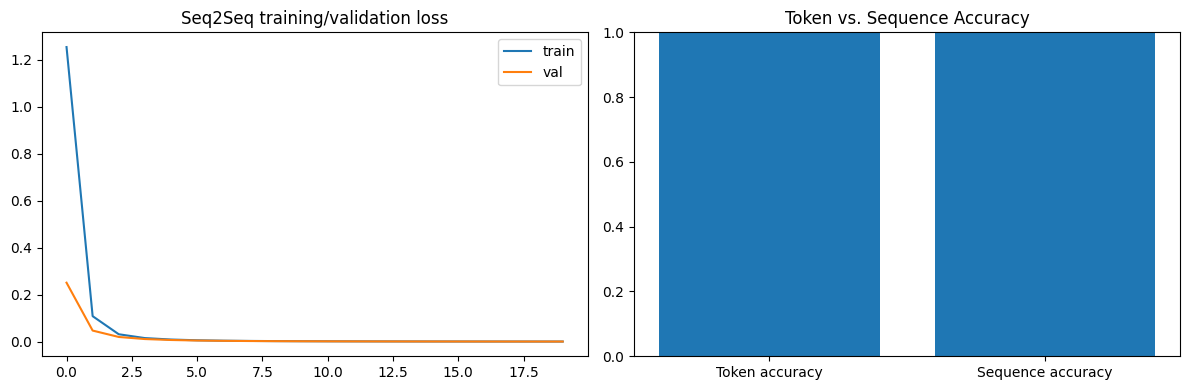

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(seq2seq_history.history["loss"], label="train")
ax[0].plot(seq2seq_history.history["val_loss"], label="val")
ax[0].set_title("Seq2Seq training/validation loss"); ax[0].legend()
ax[1].bar(["Token accuracy", "Sequence accuracy"], [token_accuracy, sequence_accuracy])
ax[1].set_ylim(0, 1)
ax[1].set_title("Token vs. Sequence Accuracy")
plt.tight_layout(); plt.show()

In [39]:
consolidated_rows = []
for rnn_type in ["RNN", "LSTM", "GRU"]:
    r = eval_results[rnn_type]
    consolidated_rows.append({
        "Model": rnn_type, "Accuracy": round(r["accuracy"], 2),
        "Precision": round(r["precision"], 2), "Recall": round(r["recall"], 2),
        "F1": round(r["f1"], 2), "Parameters": results[rnn_type]["params"],
    })
if len(video_paths) > 0 and len(X_vid_feats) >= 6:
    vid_acc = accuracy_score(yv_te, y_vid_pred) * 100
    vid_prec = precision_score(yv_te, y_vid_pred, average="macro", zero_division=0) * 100
    vid_rec = recall_score(yv_te, y_vid_pred, average="macro", zero_division=0) * 100
    vid_f1 = f1_score(yv_te, y_vid_pred, average="macro", zero_division=0) * 100
    consolidated_rows.append({
        "Model": "CNN-LSTM (video)", "Accuracy": round(vid_acc, 2),
        "Precision": round(vid_prec, 2), "Recall": round(vid_rec, 2),
        "F1": round(vid_f1, 2), "Parameters": video_model.count_params(),
    })

consolidated_df = pd.DataFrame(consolidated_rows)
print("Sequence-classification models:")
display(consolidated_df)

seq2seq_table = pd.DataFrame({
    "Metric": ["Token Accuracy", "Sequence Accuracy", "Training Loss", "Validation Loss"],
    "Value": [round(token_accuracy, 4), round(sequence_accuracy, 4),
              round(seq2seq_history.history['loss'][-1], 4),
              round(seq2seq_history.history['val_loss'][-1], 4)]
})
print("\nSequence-to-sequence task:")
display(seq2seq_table)

Sequence-classification models:


,Model,Accuracy,Precision,Recall,F1,Parameters
0,RNN,81.67,82.23,81.67,81.13,1974
1,LSTM,94.17,94.12,94.17,94.13,6006
2,GRU,95.00,95.03,95.00,95.00,4758



Sequence-to-sequence task:


,Metric,Value
0,Token Accuracy,1.0000
1,Sequence Accuracy,1.0000
2,Training Loss,0.0003
3,Validation Loss,0.0002
